# 머신러닝 최종과제 - 김지현

**데이터:** `diabetes.csv`


## 실행 환경 및 라이브러리

In [52]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

RANDOM_STATE = 42


## 1. 탐색적 데이터 분석(EDA) 및 전처리 파이프라인

### 1-1. 데이터 구조 탐색 및 기초 분석

In [53]:
DATA_PATH = Path("diabetes.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("diabetes.csv를 노트북과 같은 폴더에 두어 주세요.")

df = pd.read_csv(DATA_PATH)
print(f"데이터 크기: {df.shape[0]}행 × {df.shape[1]}열")
display(df.head())
print("\n[변수별 자료형과 non-null 개수]")
df.info()

데이터 크기: 768행 × 9열


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



[변수별 자료형과 non-null 개수]
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [54]:
print("[일반 결측치 개수]")
display(df.isnull().sum().to_frame("missing_count"))

print("[기술통계]")
display(df.describe().T)

print("[중복 행 수]", df.duplicated().sum())
print("[Outcome 분포]")
display(df["Outcome"].value_counts().rename("count").to_frame().assign(
    ratio=lambda x: (x["count"] / len(df)).round(4)
))

[일반 결측치 개수]


,missing_count
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


[기술통계]


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


[중복 행 수] 0
[Outcome 분포]


,count,ratio
Outcome,,
0,500,0.651
1,268,0.349


### 생리학적으로 오류인 0값 확인

`Pregnancies`와 `Outcome`의 0은 정상값이다. 반면 Glucose, BloodPressure, SkinThickness, Insulin, BMI의 0은 생리학적으로 타당하지 않으므로 결측치로 처리한다.

In [55]:
zero_error_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_summary = pd.DataFrame({
    "zero_count": (df[zero_error_columns] == 0).sum(),
    "zero_ratio": ((df[zero_error_columns] == 0).mean() * 100).round(2)
}).sort_values("zero_ratio", ascending=False)
display(zero_summary)

,zero_count,zero_ratio
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


### 1-2. 데이터 시각화 및 인사이트 도출

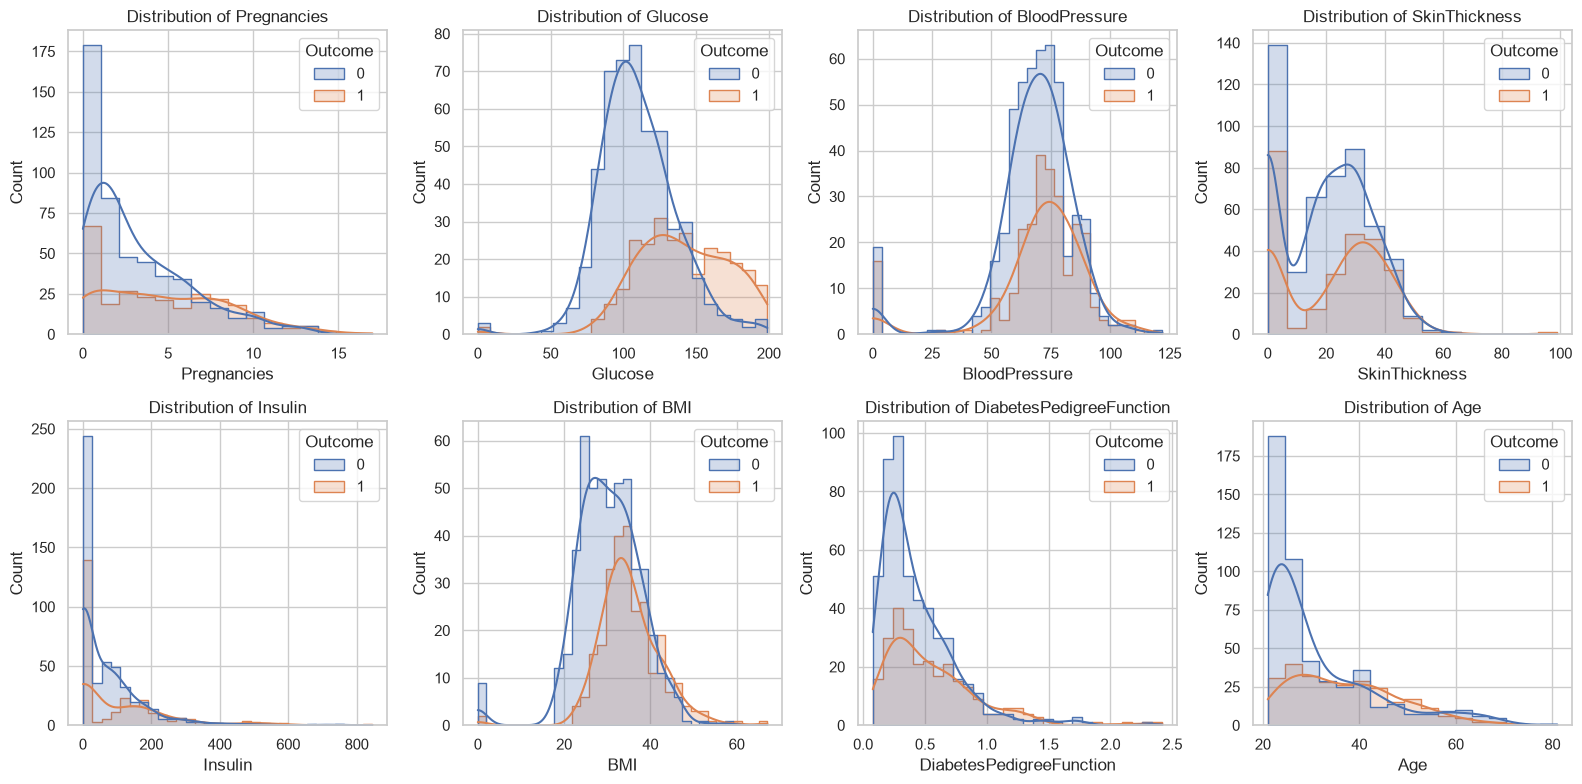

In [56]:
feature_columns = [c for c in df.columns if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for column, ax in zip(feature_columns, axes.ravel()):
    sns.histplot(data=df, x=column, hue="Outcome", kde=True, element="step", ax=ax)
    ax.set_title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

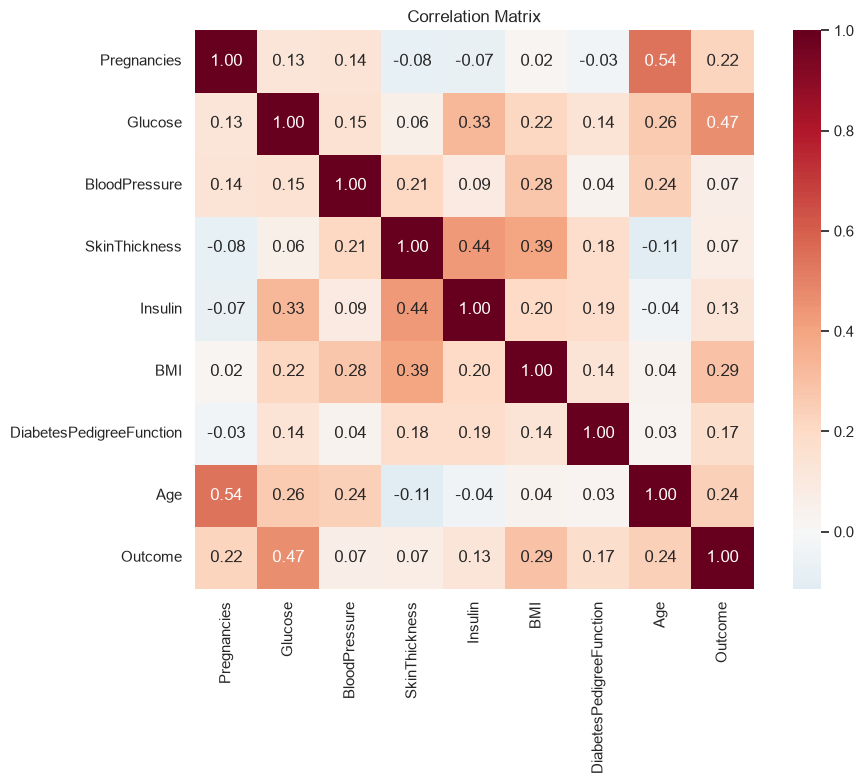

,correlation_with_outcome
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


In [57]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

outcome_corr = corr["Outcome"].drop("Outcome").sort_values(key=abs, ascending=False)
display(outcome_corr.rename("correlation_with_outcome").to_frame())

### 시각화 및 기초 통계 해석

- `Outcome`은 0이 더 많으므로 Accuracy와 함께 Recall, F1-score, ROC-AUC를 평가한다.
- `Glucose`가 `Outcome`과 가장 높은 양의 상관관계를 보였고, `BMI`, `Age`, `Pregnancies`가 뒤를 이었다.
- `Insulin`과 `SkinThickness`의 0값이 많으므로 행 삭제 대신 중앙값으로 대체한다.


### 1-3. 전처리 파이프라인 구축 및 선택 근거

생리학적으로 불가능한 0은 `NaN`으로 바꾸고, 이상치 영향을 줄이기 위해 중앙값으로 대체한다. 로지스틱 회귀의 규제가 변수 단위에 영향을 받지 않도록 `StandardScaler`를 적용한다. 현재 입력 변수는 모두 수치형이므로 실제 범주형 인코딩 대상은 없다. 전처리는 파이프라인 안에서 수행하여 데이터 누수를 방지한다.


In [58]:
X = df.drop(columns="Outcome").copy()
y = df["Outcome"].copy()

# 생리학적으로 불가능한 0값만 누락값으로 변환
X[zero_error_columns] = X[zero_error_columns].replace(0, np.nan)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformers = [("num", numeric_pipeline, numeric_features)]
if categorical_features:
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])
    transformers.append(("cat", categorical_pipeline, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("학습 데이터:", X_train.shape, "테스트 데이터:", X_test.shape)
print("학습 데이터 양성 비율:", round(y_train.mean(), 4))
print("테스트 데이터 양성 비율:", round(y_test.mean(), 4))

학습 데이터: (614, 8) 테스트 데이터: (154, 8)
학습 데이터 양성 비율: 0.3485
테스트 데이터 양성 비율: 0.3506


## 2. 머신러닝 모델 학습, 과적합 점검 및 하이퍼파라미터 튜닝

### [문항 2-1] 분류 모델 학습과 성능 측정

`Outcome`은 당뇨 여부를 나타내는 0/1 값이므로 이진 분류 문제이다. 따라서 분류 모델인 **로지스틱 회귀(Logistic Regression)**만 사용한다.

In [59]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred),
        "recall": recall_score(y_test, test_pred),
        "f1": f1_score(y_test, test_pred),
        "roc_auc": roc_auc_score(y_test, test_prob)
    }

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
baseline_model.fit(X_train, y_train)

baseline_result = evaluate_classifier(
    baseline_model, X_train, y_train, X_test, y_test, "Baseline Logistic Regression"
)
display(pd.DataFrame([baseline_result]).set_index("model").round(4))

baseline_pred = baseline_model.predict(X_test)
print(classification_report(y_test, baseline_pred, digits=4))

,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
model,,,,,,
Baseline Logistic Regression,0.7964,0.7078,0.6,0.5,0.5455,0.813


              precision    recall  f1-score   support

           0     0.7523    0.8200    0.7847       100
           1     0.6000    0.5000    0.5455        54

    accuracy                         0.7078       154
   macro avg     0.6761    0.6600    0.6651       154
weighted avg     0.6989    0.7078    0.7008       154



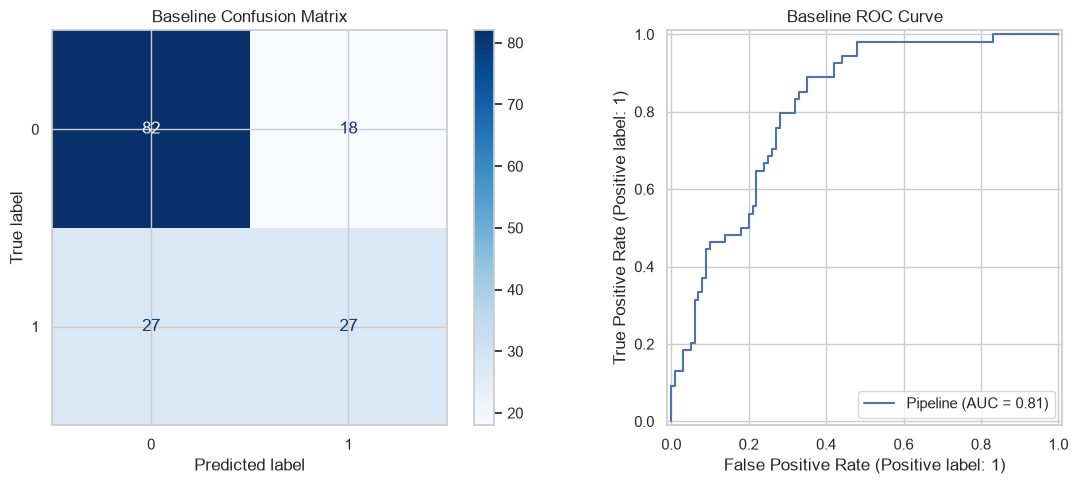

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Baseline Confusion Matrix")
RocCurveDisplay.from_estimator(baseline_model, X_test, y_test, ax=axes[1])
axes[1].set_title("Baseline ROC Curve")
plt.tight_layout()
plt.show()

### 2-2. 평가지표 선정 이유와 오류 해석

- 클래스가 불균형하므로 Accuracy만 사용하지 않고 Precision, Recall, F1-score, ROC-AUC를 함께 확인한다.
- 당뇨 환자를 정상으로 예측하는 False Negative가 중요하므로 Recall을 중점적으로 본다.
- 예측 오류는 제한된 데이터, 결측값, 측정 오차, 데이터에 포함되지 않은 생활습관 등의 영향으로 발생할 수 있다.


### 2-3. 규제·교차 검증·하이퍼파라미터 튜닝

L1/L2 규제, 규제 강도 `C`, 반복 횟수, class weight를 `GridSearchCV`로 비교한다. 클래스 비율을 유지하는 5-fold `StratifiedKFold`를 사용하고 F1-score가 가장 높은 모델을 선택한다.


In [61]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_cv_f1 = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring="f1")
print("기본 모델 5-fold F1:", np.round(baseline_cv_f1, 4))
print(f"기본 모델 평균 F1: {baseline_cv_f1.mean():.4f} ± {baseline_cv_f1.std():.4f}")

tuning_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(solver="liblinear", random_state=RANDOM_STATE))
])

param_grid = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__max_iter": [500, 1000],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("최적 하이퍼파라미터:", grid_search.best_params_)
print(f"최적 교차 검증 F1: {grid_search.best_score_:.4f}")

기본 모델 5-fold F1: [0.6389 0.6667 0.6944 0.6494 0.6234]
기본 모델 평균 F1: 0.6545 ± 0.0244
최적 하이퍼파라미터: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 500, 'classifier__penalty': 'l2'}
최적 교차 검증 F1: 0.6792


In [62]:
improved_result = evaluate_classifier(
    best_model, X_train, y_train, X_test, y_test, "Tuned Logistic Regression"
)
comparison = pd.DataFrame([baseline_result, improved_result]).set_index("model")
display(comparison.round(4))

improved_pred = best_model.predict(X_test)
print("[개선 모델 분류 보고서]")
print(classification_report(y_test, improved_pred, digits=4))

best_index = grid_search.best_index_
best_cv_train_f1 = grid_search.cv_results_["mean_train_score"][best_index]
best_cv_valid_f1 = grid_search.cv_results_["mean_test_score"][best_index]
print(f"최적 모델 CV 학습 F1: {best_cv_train_f1:.4f}")
print(f"최적 모델 CV 검증 F1: {best_cv_valid_f1:.4f}")
print(f"CV 과적합 격차: {best_cv_train_f1 - best_cv_valid_f1:.4f}")

,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
model,,,,,,
Baseline Logistic Regression,0.7964,0.7078,0.6000,0.5000,0.5455,0.8130
Tuned Logistic Regression,0.7655,0.7208,0.5846,0.7037,0.6387,0.8106


[개선 모델 분류 보고서]
              precision    recall  f1-score   support

           0     0.8202    0.7300    0.7725       100
           1     0.5846    0.7037    0.6387        54

    accuracy                         0.7208       154
   macro avg     0.7024    0.7169    0.7056       154
weighted avg     0.7376    0.7208    0.7256       154

최적 모델 CV 학습 F1: 0.6805
최적 모델 CV 검증 F1: 0.6792
CV 과적합 격차: 0.0014


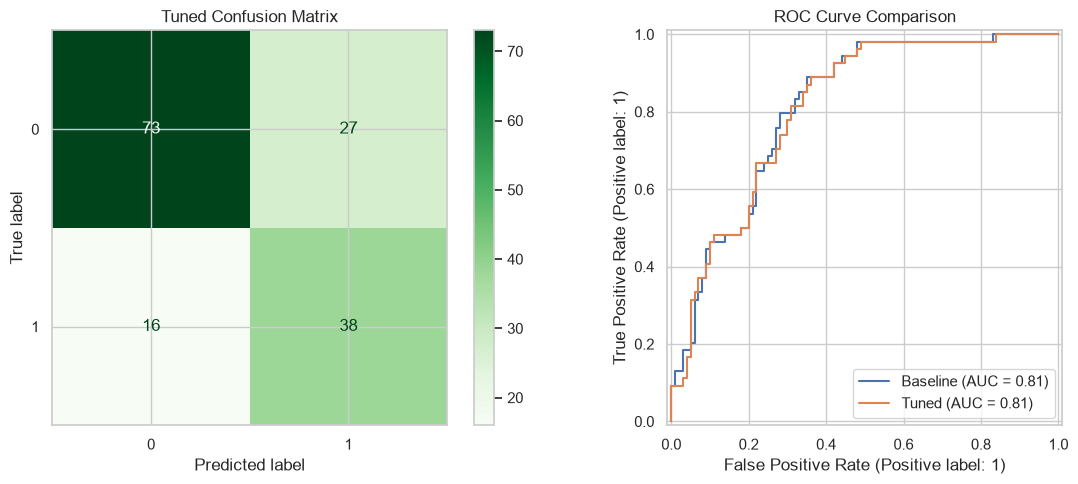

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, improved_pred, cmap="Greens", ax=axes[0])
axes[0].set_title("Tuned Confusion Matrix")
RocCurveDisplay.from_estimator(baseline_model, X_test, y_test, ax=axes[1], name="Baseline")
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1], name="Tuned")
axes[1].set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

### 개선 결과 해석

튜닝 후 Accuracy는 **0.7078 → 0.7208**, Recall은 **0.5000 → 0.7037**, F1은 **0.5455 → 0.6387**로 향상되었다. Precision은 **0.6000 → 0.5846**으로 소폭 낮아졌지만, 당뇨 환자를 놓치는 False Negative가 감소했다. CV 학습 F1(0.6805)과 검증 F1(0.6792)의 차이가 **0.0014**로 작아 심한 과적합은 나타나지 않았다.


## 3. Hugging Face Gemma를 활용한 뉴스 기사 Few-shot 분류

### 실행 전 확인

Gemma 실행 시 Hugging Face의 모델 이용 동의와 충분한 메모리가 필요하다. 현재 CPU 환경에서는 `RUN_GEMMA=False`로 두었으며, 실행 가능한 환경에서는 `True`로 변경한다.


In [64]:
RUN_GEMMA = False
GEMMA_MODEL_ID = "google/gemma-2-2b-it"
NEWS_LABELS = ["정치", "경제", "사회", "생활/문화", "세계", "IT/과학", "스포츠"]

news_test_set = [
    {"text": "한국은행이 기준금리를 동결하고 올해 물가 전망치를 발표했다.", "label": "경제"},
    {"text": "프로야구 정규리그에서 서울 팀이 연장전 끝에 역전승을 거뒀다.", "label": "스포츠"},
    {"text": "국회는 본회의를 열어 교육 관련 개정 법안을 표결했다.", "label": "정치"},
    {"text": "연구진이 전력 소비를 줄인 차세대 인공지능 반도체를 공개했다.", "label": "IT/과학"},
    {"text": "태풍의 영향으로 남부 지역 학교가 휴업하고 항공편이 결항됐다.", "label": "사회"},
]
print("Gemma 실행 여부:", RUN_GEMMA)
print("평가 기사 수:", len(news_test_set))

Gemma 실행 여부: False
평가 기사 수: 5


### 3-1. 사전학습 Gemma 모델과 토크나이저 로드

In [65]:
if RUN_GEMMA:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

    tokenizer = AutoTokenizer.from_pretrained(GEMMA_MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        GEMMA_MODEL_ID,
        dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
        low_cpu_mem_usage=True
    )
    gemma_generator = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer
    )
    print("모델 로드 완료:", GEMMA_MODEL_ID)
    print("모델 실행 장치:", model.device)
else:
    print("[SKIP] RUN_GEMMA=True로 변경하면 Gemma 모델과 토크나이저를 로드합니다.")

[SKIP] RUN_GEMMA=True로 변경하면 Gemma 모델과 토크나이저를 로드합니다.


### 3-2. Few-shot 프롬프트 설계 및 뉴스 분류 추론

카테고리별 예시를 제공하고 출력은 카테고리 한 단어로 제한한다.

In [66]:
few_shot_examples = [
    ("정부가 내년도 예산안을 국회에 제출하고 여야가 심사 일정에 합의했다.", "정치"),
    ("원달러 환율이 하락하고 코스피 지수가 상승 마감했다.", "경제"),
    ("경찰이 보이스피싱 조직을 검거해 피해금을 회수했다.", "사회"),
    ("박물관이 조선시대 회화 특별전을 다음 달 개막한다.", "생활/문화"),
    ("유럽연합 정상들이 기후 정책과 무역 문제를 논의했다.", "세계"),
    ("국내 연구팀이 양자컴퓨터 오류를 줄이는 새 기술을 개발했다.", "IT/과학"),
    ("축구 대표팀이 아시안컵 예선에서 3대 0으로 승리했다.", "스포츠"),
]

def build_news_prompt(article, n_shots=7):
    selected = few_shot_examples[:n_shots]
    examples_text = "\n".join(
        f"기사: {text}\n카테고리: {label}" for text, label in selected
    )
    labels_text = ", ".join(NEWS_LABELS)
    return f"""당신은 한국어 뉴스 분류기입니다.
가능한 카테고리: {labels_text}
아래 예시를 참고해 새 기사의 카테고리를 반드시 목록 중 한 단어로만 답하세요.

{examples_text}

기사: {article}
카테고리:"""

sample_prompt = build_news_prompt(news_test_set[0]["text"], n_shots=7)
print(sample_prompt)

당신은 한국어 뉴스 분류기입니다.
가능한 카테고리: 정치, 경제, 사회, 생활/문화, 세계, IT/과학, 스포츠
아래 예시를 참고해 새 기사의 카테고리를 반드시 목록 중 한 단어로만 답하세요.

기사: 정부가 내년도 예산안을 국회에 제출하고 여야가 심사 일정에 합의했다.
카테고리: 정치
기사: 원달러 환율이 하락하고 코스피 지수가 상승 마감했다.
카테고리: 경제
기사: 경찰이 보이스피싱 조직을 검거해 피해금을 회수했다.
카테고리: 사회
기사: 박물관이 조선시대 회화 특별전을 다음 달 개막한다.
카테고리: 생활/문화
기사: 유럽연합 정상들이 기후 정책과 무역 문제를 논의했다.
카테고리: 세계
기사: 국내 연구팀이 양자컴퓨터 오류를 줄이는 새 기술을 개발했다.
카테고리: IT/과학
기사: 축구 대표팀이 아시안컵 예선에서 3대 0으로 승리했다.
카테고리: 스포츠

기사: 한국은행이 기준금리를 동결하고 올해 물가 전망치를 발표했다.
카테고리:


In [67]:
def normalize_label(generated_text):
    # 모델이 설명을 붙이더라도 허용된 레이블만 추출
    for label in sorted(NEWS_LABELS, key=len, reverse=True):
        if label in generated_text:
            return label
    return "기타"

def classify_news(article, n_shots=7, temperature=0.0, top_p=1.0, top_k=50):
    prompt = build_news_prompt(article, n_shots=n_shots)
    generation_kwargs = {
        "max_new_tokens": 12,
        "return_full_text": False,
        "do_sample": temperature > 0,
        "pad_token_id": tokenizer.eos_token_id,
    }
    if temperature > 0:
        generation_kwargs.update(
            temperature=temperature, top_p=top_p, top_k=top_k
        )
    output = gemma_generator(prompt, **generation_kwargs)
    raw_answer = output[0]["generated_text"].strip()
    return normalize_label(raw_answer), raw_answer

if RUN_GEMMA:
    predicted_label, raw_answer = classify_news(news_test_set[0]["text"])
    print("기사:", news_test_set[0]["text"])
    print("실제 카테고리:", news_test_set[0]["label"])
    print("Gemma 원문 출력:", raw_answer)
    print("최종 분류:", predicted_label)
else:
    print("[SKIP] RUN_GEMMA=True로 변경하면 Few-shot 뉴스 분류 추론을 수행합니다.")

[SKIP] RUN_GEMMA=True로 변경하면 Few-shot 뉴스 분류 추론을 수행합니다.


### 3-3. Generation 하이퍼파라미터 및 Few-shot 개수 실험

temperature, top-p, top-k와 Few-shot 개수를 변경하여 정확도와 반복 일관성을 비교한다.

In [68]:
experiment_conditions = [
    {"condition": "A_greedy_7shot", "n_shots": 7, "temperature": 0.0, "top_p": 1.0, "top_k": 50},
    {"condition": "B_lowtemp_7shot", "n_shots": 7, "temperature": 0.2, "top_p": 0.9, "top_k": 40},
    {"condition": "C_hightemp_7shot", "n_shots": 7, "temperature": 1.0, "top_p": 0.95, "top_k": 50},
    {"condition": "D_greedy_3shot", "n_shots": 3, "temperature": 0.0, "top_p": 1.0, "top_k": 50},
]
display(pd.DataFrame(experiment_conditions))

,condition,n_shots,temperature,top_p,top_k
0,A_greedy_7shot,7,0.0,1.00,50
1,B_lowtemp_7shot,7,0.2,0.90,40
2,C_hightemp_7shot,7,1.0,0.95,50
3,D_greedy_3shot,3,0.0,1.00,50


In [69]:
def run_experiments(repeats=3):
    rows = []
    for condition in experiment_conditions:
        for repeat in range(repeats):
            for item in news_test_set:
                prediction, raw = classify_news(
                    item["text"],
                    n_shots=condition["n_shots"],
                    temperature=condition["temperature"],
                    top_p=condition["top_p"],
                    top_k=condition["top_k"]
                )
                rows.append({
                    "condition": condition["condition"], "repeat": repeat + 1,
                    "text": item["text"], "actual": item["label"],
                    "predicted": prediction, "raw_answer": raw,
                    "correct": prediction == item["label"]
                })
    detail = pd.DataFrame(rows)
    accuracy = detail.groupby("condition")["correct"].mean().rename("accuracy")
    consistency = (
        detail.groupby(["condition", "text"])["predicted"]
        .agg(lambda s: s.value_counts(normalize=True).iloc[0])
        .groupby("condition").mean().rename("consistency")
    )
    return detail, pd.concat([accuracy, consistency], axis=1).reset_index()

if RUN_GEMMA:
    gemma_experiment_detail, gemma_experiment_summary = run_experiments(repeats=3)
    display(gemma_experiment_summary.round(4))
    display(gemma_experiment_detail.head(10))
else:
    print("[SKIP] RUN_GEMMA=True로 변경하면 조건별 정확도와 일관성을 계산합니다.")

[SKIP] RUN_GEMMA=True로 변경하면 조건별 정확도와 일관성을 계산합니다.


### Gemma 실험 결과 해석 기준

- 정확도는 정답 카테고리와 일치한 비율이고, 일관성은 동일 기사를 반복 분류했을 때 최빈 레이블이 나온 비율이다.
- temperature가 높으면 출력이 다양해져 분류 일관성이 낮아질 수 있다.
- Few-shot 예시가 줄면 일부 카테고리의 예시가 없어져 정확도가 낮아질 수 있다.
